import important libaries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load The Mercari Dataset:
df = pd.read_csv("D:\Career\Projects\mercari-price-analysis\data\mercari_sample.csv")

# Greetings 

In [3]:
df.shape  # (rows, cols)

(50000, 8)

In [4]:
df.info()    # dtypes + null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   train_id           50000 non-null  int64  
 1   name               50000 non-null  object 
 2   item_condition_id  50000 non-null  int64  
 3   category_name      49763 non-null  object 
 4   brand_name         28416 non-null  object 
 5   price              50000 non-null  float64
 6   shipping           50000 non-null  int64  
 7   item_description   50000 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 3.1+ MB


In [5]:
df.head()    # first 5 rows

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,NaN,35.0,1,New with tags. Leather horses. Retail for [rm]...
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,NaN,44.0,0,Complete with certificate of authenticity


In [6]:
df.describe()   # stats for numeric columns

,train_id,item_condition_id,price,shipping
count,50000.000000,50000.000000,50000.000000,50000.000000
mean,24999.500000,1.908660,26.651450,0.448340
std,14433.901067,0.904706,38.208462,0.497329
min,0.000000,1.000000,0.000000,0.000000
25%,12499.750000,1.000000,10.000000,0.000000
50%,24999.500000,2.000000,17.000000,0.000000
75%,37499.250000,3.000000,29.000000,1.000000
max,49999.000000,5.000000,1506.000000,1.000000


In [7]:
df.isnull().sum() / len(df) * 100    # null %

train_id              0.000
name                  0.000
item_condition_id     0.000
category_name         0.474
brand_name           43.168
price                 0.000
shipping              0.000
item_description      0.000
dtype: float64

# Cleaning 

In [8]:
df = df.dropna(subset=["category_name"])  # 0.47% data -> safe to drop

In [9]:
df["brand_name"] = df["brand_name"].fillna("No Brand")  # 43% data -> big loss if we drop it so just fill it with "No Brand"

In [10]:
# Check for duplicates
df.duplicated().sum()

np.int64(0)

In [11]:
# Check price = 0 rows - are these real?
df[df["price"]==0][["name", "category_name", "brand_name"]].head(10)

,name,category_name,brand_name
1325,Alabama Crimson Tide Quality Lanyard,Sports & Outdoors/Fan Shop/NCAA,No Brand
2544,Levi leggings,"Women/Jeans/Slim, Skinny",Levi's®
2712,Simple Red Lace Lingerie Top,Women/Underwear/G-Strings & Thongs,No Brand
3576,Turquoise 15 Pc Makeup Brush Set,Beauty/Tools & Accessories/Makeup Brushes & Tools,No Brand
3761,Girls size 7/8,Kids/Girls (4+)/Tops & T-Shirts,No Brand
5237,Nursing Bra,Women/Underwear/Bras,Motherhood Maternity
6175,"Multi Listing Bundled Package, Thanks",Electronics/Media/DVD,No Brand
7116,Nike Dri-Fit High Power Speed Tights,"Women/Athletic Apparel/Pants, Tights, Leggings",Nike
7622,Hands free earpiece,Electronics/Cell Phones & Accessories/Headsets,No Brand
10812,Vampire candy bowl,Home/Seasonal Décor/Halloween,No Brand


In [12]:
# Verfiy Cleaning:
print("\nNull counts after cleaning:\n", df.isnull().sum())
print("\nFinal shape:", df.shape)


Null counts after cleaning:
 train_id             0
name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
dtype: int64

Final shape: (49763, 8)


# Feature Engineering

In [31]:
# split categories
df["main_category"] = df["category_name"].str.split("/").str[0]
df["sub_category"] = df["category_name"].str.split("/").str[1]
df["sub_sub"] = df["category_name"].str.split("/").str[2]

In [32]:
# Normalized Brand Names
df["brand_name"] = df["brand_name"].str.lower().str.strip()

In [33]:
# has_description - is the description meaningful?
df["has_description"] = df["item_description"].apply(
    lambda x: 0 if x == "No description yet" else 1
)

In [34]:
# name_length - longer names might indicate more detail = higher price?
df["name_length"] = df["name"].str.len()

In [35]:
# Map condition to label
condition_map = {1: "New", 2: "Like New", 3: "Good", 4: "Fair", 5: "Poor"}
df["condition_label"] = df["item_condition_id"].map(condition_map)

# Analysis

In [36]:
# Average Price per Main Category
df.groupby("main_category")["price"].mean().sort_values(ascending=False).round(2)    # Electronics is the most profitabel category for mercari 

main_category
Electronics               34.93
Men                       34.87
Vintage & Collectibles    29.28
Women                     28.69
Sports & Outdoors         25.65
Home                      24.74
Other                     20.54
Kids                      20.17
Beauty                    19.69
Handmade                  18.24
Name: price, dtype: float64

In [37]:
# Item count per Main Category
df.groupby("main_category").size().sort_values(ascending=False).round(2)

main_category
Women                     22426
Beauty                     7090
Kids                       5734
Electronics                4225
Men                        3057
Home                       2221
Vintage & Collectibles     1585
Other                      1539
Handmade                   1045
Sports & Outdoors           841
dtype: int64

In [38]:
# Full agg tabel - avg, count, max per category
summary = df.groupby("main_category")["price"].agg(
    avg_price="mean",
    count="count",
    max_price="max",
    min_price="min"
).sort_values("avg_price", ascending=False).round(2)

In [39]:
# Avg Price by Condition
df.groupby("condition_label")["price"].mean().sort_values(ascending=False).round(2)

condition_label
Poor        34.30
Like New    27.72
Good        26.62
New         26.26
Fair        22.16
Name: price, dtype: float64

In [40]:
# Avg Price by Condition + Shipping
df.groupby(["condition_label", "shipping"])["price"].mean().round(2).reset_index()

,condition_label,shipping,price
0,Fair,0,22.57
1,Fair,1,21.30
2,Good,0,28.22
3,Good,1,23.56
4,Like New,0,29.74
5,Like New,1,24.47
6,New,0,32.83
7,New,1,21.17
8,Poor,0,37.53
9,Poor,1,28.86


In [47]:
# log transformation
df["log_price"] = np.log1p(df["price"])

In [49]:
# IQR
Q1 = np.percentile(df["price"], 25)
Q3 = np.percentile(df["price"], 75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [50]:
# item % by category
df.groupby("main_category").size() / len(df) * 100

main_category
Beauty                    14.247533
Electronics                8.490244
Handmade                   2.099954
Home                       4.463155
Kids                      11.522617
Men                        6.143118
Other                      3.092659
Sports & Outdoors          1.690011
Vintage & Collectibles     3.185097
Women                     45.065611
dtype: float64

# Brand Analysis

In [51]:
# Exclude "no brand" sentinel so it doesn't pollute brand ranking results
branded = df[df["brand_name"] != "no brand"]

# Top luxury brands
branded.groupby("brand_name")["price"].mean().sort_values(ascending=False).head(5)

brand_name
celine               539.500000
generic              486.000000
canada goose         415.000000
valentino            412.500000
alexander mcqueen    398.666667
Name: price, dtype: float64

# Charts

In [52]:
# ── Design Tokens — change here, updates every chart ─────────────────────────
COLORS = {
    "primary"  : "#4F46E5",   # Indigo
    "secondary": "#0EA5E9",   # Sky blue
    "accent"   : "#F59E0B",   # Amber
    "positive" : "#10B981",   # Emerald
    "negative" : "#EF4444",   # Red
    "neutral"  : "#6B7280",   # Slate gray
}

In [53]:
# ── Shared Styling Helper ─────────────────────────────────────────────────────
def style_ax(ax, title, xlabel, ylabel, rotate_x=False):
    """Apply consistent chart styling: no top/right spines, soft grid, bold title."""
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3, color="gray", linestyle="--")
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=9)
    if rotate_x:
        ax.tick_params(axis="x", rotation=45)

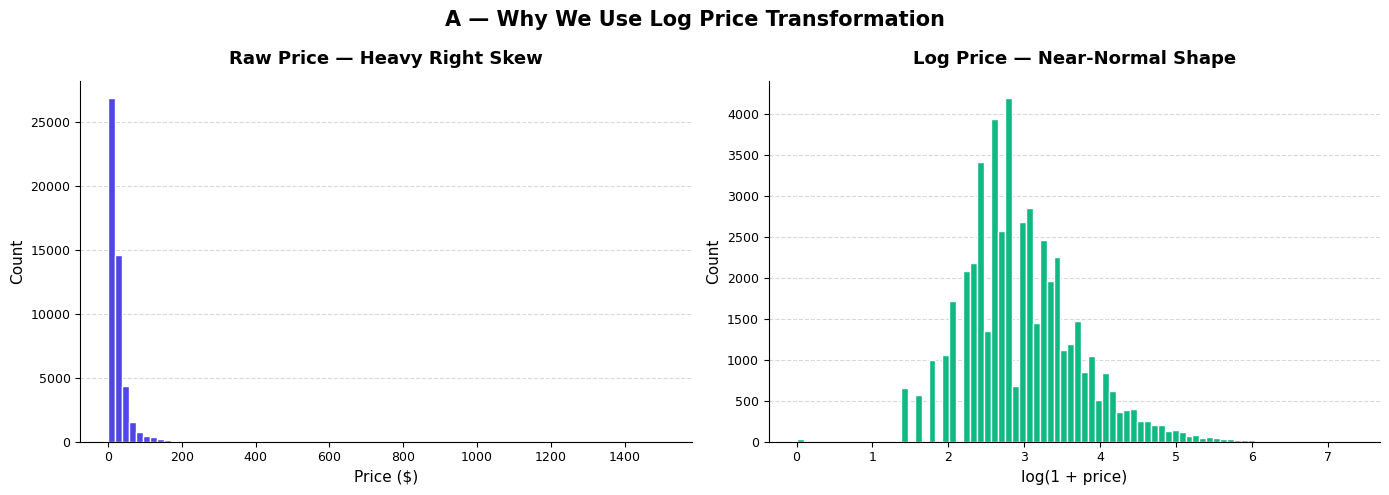

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["price"], bins=80, color=COLORS["primary"],  edgecolor="white")
style_ax(axes[0], "Raw Price — Heavy Right Skew", "Price ($)", "Count")

axes[1].hist(df["log_price"], bins=80, color=COLORS["positive"], edgecolor="white")
style_ax(axes[1], "Log Price — Near-Normal Shape", "log(1 + price)", "Count")

fig.suptitle("A — Why We Use Log Price Transformation", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()



# Raw Price is dominated by long right tail($1500). log1p compress the range from 0-1500 to 0-7.3, producing a near normal distribution!

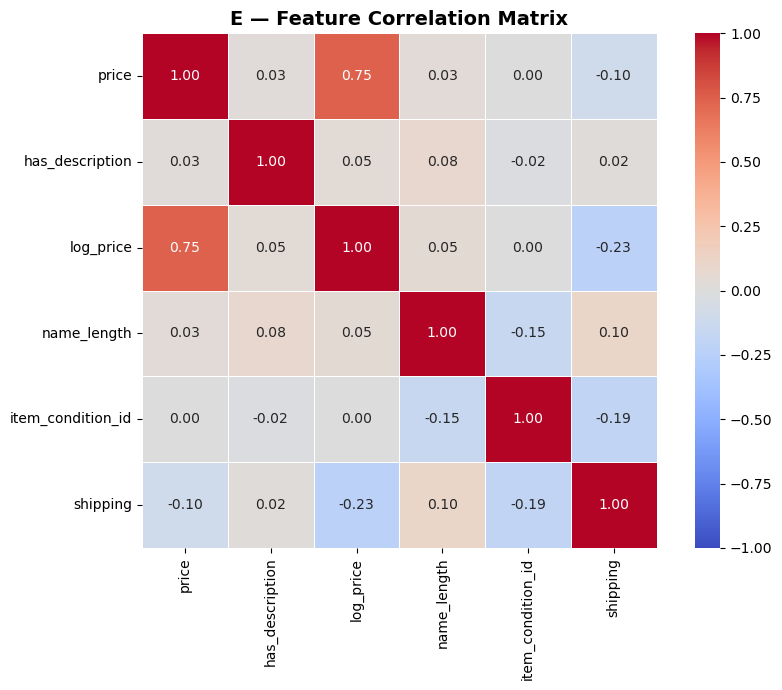

In [68]:
# Which features have the strongest linear relationship with price?
numeric_cols = ["price", "has_description", "log_price", "name_length", "item_condition_id", "shipping"]

corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)

ax.set_title("E — Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


#  log_price and price are perfectly correlated (by construction). item_condition_id has a slight negative correlation with 
# price — lower condition IDs (1 = New) correspond to higher prices. 
# shipping shows a positive correlation — seller-paid shipping tends to come with higher-priced listings.